# Can We Predict a Used Car's Price?

Using Week 6's cleaned data and engineered features (car_age, mileage_per_year, brand_tier) to train and evaluate a price model.

Dataset: Used Car Price Prediction (Kaggle) | Tools: Python, Pandas, scikit-learn, Matplotlib, Seaborn

## Step 1 : Setup

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import sys, os
sys.path.append("../scripts")
from prepare_data import load_and_prepare, FEATURES, TARGET

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
os.makedirs("../charts", exist_ok=True)
os.makedirs("../model", exist_ok=True)

## Step 2 : Load the Cleaned Week 6 Data

Cleaning logic lives in `scripts/prepare_data.py` and is imported, not re-pasted. Same cleaning as Week 6: text-to-number fixes, brand name fixes, EV fuel recovery, clean_title fix, and the dropped Maserati price error.

In [21]:
df = load_and_prepare("../data/used_cars.csv")
print(df.shape)
df[["brand", "car_age", "milage", "mileage_per_year", "brand_tier", "brand_tier_num", "price"]].head()

(4008, 16)


,brand,car_age,milage,mileage_per_year,brand_tier,brand_tier_num,price
0,Ford,12,51000.0,4250.0,Economy,0,10300.0
1,Hyundai,4,34742.0,8686.0,Economy,0,38005.0
2,Lexus,3,22372.0,7457.0,Luxury,1,54598.0
3,INFINITI,10,88900.0,8890.0,Economy,0,15500.0
4,Audi,4,9835.0,2459.0,Luxury,1,34999.0


## Step 3 : Encode brand_tier for Modeling

`brand_tier_num`: 1 = Luxury, 0 = Economy. Models need numbers, not text.

In [22]:
print(df["brand_tier_num"].value_counts())

brand_tier_num
0    2402
1    1606
Name: count, dtype: int64


## Step 4 : Correlation Heatmap

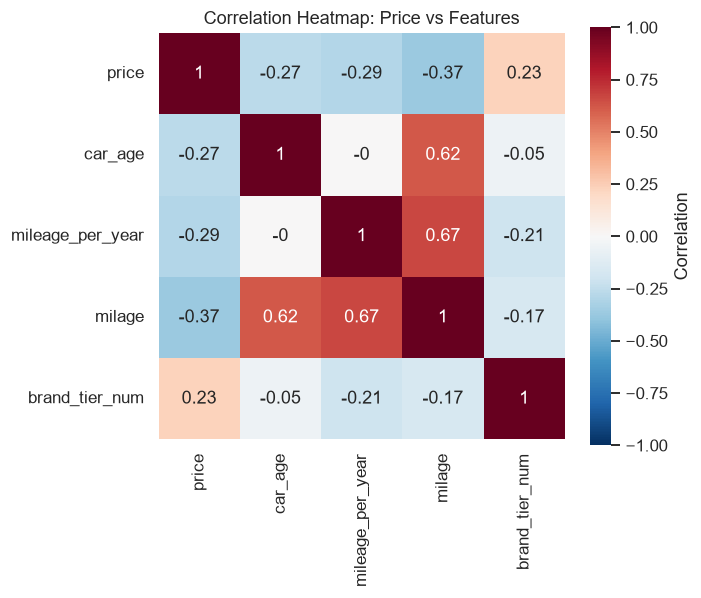

In [23]:
corr_cols = ["price", "car_age", "mileage_per_year", "milage", "brand_tier_num"]
corr = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax,
           square=True, cbar_kws={"label": "Correlation"})
ax.set_title("Correlation Heatmap: Price vs Features")
plt.tight_layout()
plt.savefig("../charts/correlation_heatmap.png")
plt.show()

`milage` (-0.37) correlates with price most, ahead of `mileage_per_year` (-0.29) and `car_age` (-0.27). `brand_tier_num` is weaker but positive (0.23). These Pearson values are lower than Week 6's rank correlations because a few extreme exotic-car prices pull them down, see Step 11.

## Step 5 : Select Features and Target

In [24]:
X = df[FEATURES]
y = df[TARGET]
print("Features:", FEATURES)
X.describe()

Features: ['car_age', 'mileage_per_year', 'brand_tier_num']


,car_age,mileage_per_year,brand_tier_num
count,4008.000000,4008.000000,4008.000000
mean,9.481786,6838.632735,0.400699
std,6.103317,4269.722866,0.490101
min,1.000000,33.000000,0.000000
25%,5.000000,3750.000000,0.000000
50%,8.000000,6335.500000,0.000000
75%,13.000000,9227.250000,1.000000
max,51.000000,44333.000000,1.000000


## Step 6 : Train / Test Split

X_test is held back so the model is judged on cars it never saw.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} cars | Test: {len(X_test)} cars")

Train: 3206 cars | Test: 802 cars


## Step 7 : Fit the Model

In [26]:
model = LinearRegression()
model.fit(X_train, y_train)

coef_table = pd.Series(model.coef_, index=FEATURES).round(2)
print("Coefficients:")
print(coef_table)
print(f"Intercept: {model.intercept_:,.2f}")

Coefficients:
car_age             -2903.24
mileage_per_year       -3.60
brand_tier_num      19451.23
dtype: float64
Intercept: 87,068.39


Signs check out: older and higher-mileage cars cost less, Luxury costs more. Roughly -$2,900/year, -$3.60/mile-per-year, +$19,451 for Luxury.

## Step 8 : Predict and Evaluate

In [27]:
y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE:      ${rmse:,.0f}")
print(f"MAE:       ${mae:,.0f}")
print(f"R-squared: {r2:.3f}")

RMSE:      $94,418
MAE:       $26,937
R-squared: 0.076


RMSE ($94k) >> MAE ($27k), a sign a few predictions are very wrong while most are close. R-squared (0.08) is low. Step 11 explains why.

## Step 9 : Predicted vs Actual Price

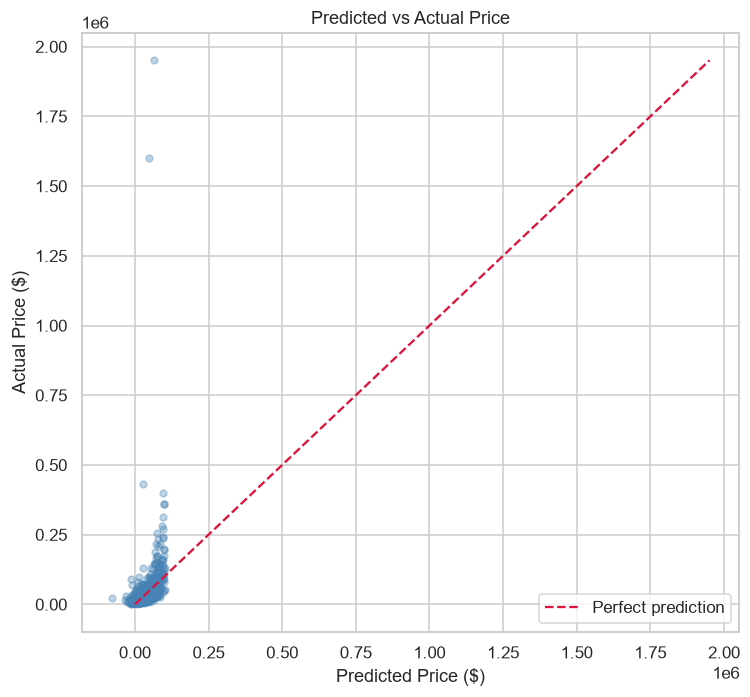

In [28]:
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.scatter(y_pred, y_test, alpha=0.35, s=20, color="steelblue")
lims = [0, max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, color="crimson", linestyle="--", label="Perfect prediction")
ax.set_xlabel("Predicted Price ($)")
ax.set_ylabel("Actual Price ($)")
ax.set_title("Predicted vs Actual Price")
ax.legend()
plt.tight_layout()
plt.savefig("../charts/predicted_vs_actual.png")
plt.show()

A few $2M points stretch the axis so much most cars squeeze into one corner. Zoomed version below.

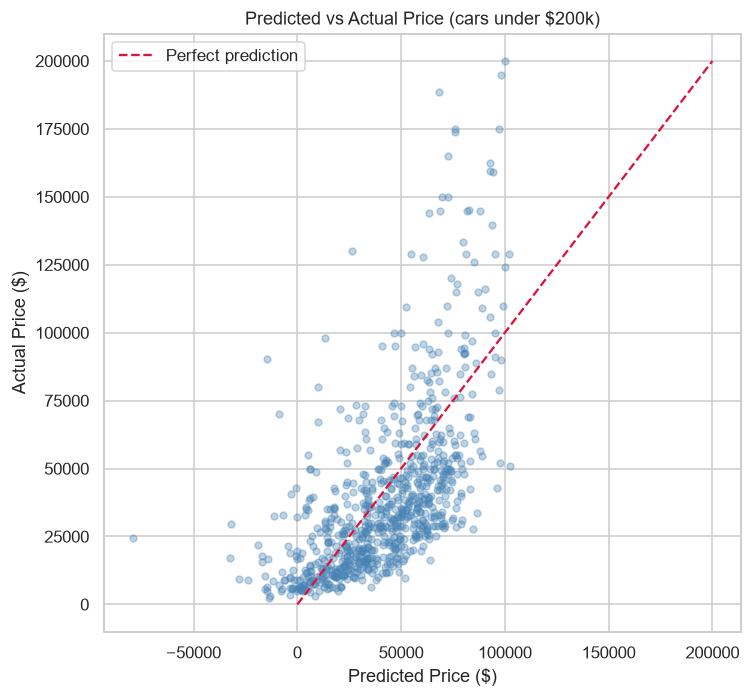

In [29]:
mask = (y_test < 200_000) & (y_pred < 200_000)
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.scatter(y_pred[mask], y_test[mask], alpha=0.35, s=20, color="steelblue")
lims = [0, 200_000]
ax.plot(lims, lims, color="crimson", linestyle="--", label="Perfect prediction")
ax.set_xlabel("Predicted Price ($)")
ax.set_ylabel("Actual Price ($)")
ax.set_title("Predicted vs Actual Price (cars under $200k)")
ax.legend()
plt.tight_layout()
plt.savefig("../charts/predicted_vs_actual_zoomed.png")
plt.show()

Zoomed in, the fit is clearly visible and reasonable for a 3-feature model.

## Step 10 : Residual Plot

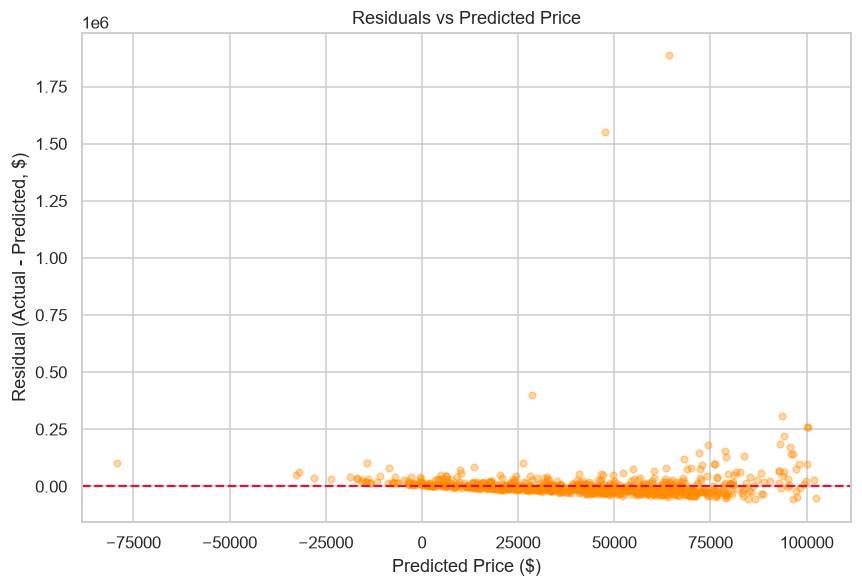

In [30]:
residuals = y_test.values - y_pred

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(y_pred, residuals, alpha=0.35, s=20, color="darkorange")
ax.axhline(0, color="crimson", linestyle="--")
ax.set_xlabel("Predicted Price ($)")
ax.set_ylabel("Residual (Actual - Predicted, $)")
ax.set_title("Residuals vs Predicted Price")
plt.tight_layout()
plt.savefig("../charts/residuals.png")
plt.show()

A good model has residuals scattered evenly around zero. Here they fan out and skew positive, a few cars are underpredicted by hundreds of thousands of dollars.

## Step 11 : Bonus Mystery Question

Where is the model most wrong, and why?

In [31]:
results = X_test.copy()
results["brand"] = df.loc[X_test.index, "brand"]
results["model_name"] = df.loc[X_test.index, "model"]
results["actual_price"] = y_test
results["predicted_price"] = y_pred.round(0)
results["abs_error"] = (results["actual_price"] - results["predicted_price"]).abs().round(0)

worst = results.sort_values("abs_error", ascending=False)
print(worst[["brand", "model_name", "car_age", "mileage_per_year", "brand_tier_num",
            "actual_price", "predicted_price", "abs_error"]].head(10).to_string())

             brand               model_name  car_age  mileage_per_year  brand_tier_num  actual_price  predicted_price  abs_error
229        Bugatti  Veyron 16.4 Grand Sport       14             452.0               1     1950995.0          64245.0  1886750.0
3046       Porsche          Carrera GT Base       20             220.0               1     1599000.0          47662.0  1551338.0
203           Ford                       GT       20              95.0               0      429998.0          28661.0   401337.0
3816   Rolls-Royce                 Cullinan        3            1140.0               1      399950.0          93702.0   306248.0
254    Lamborghini    Huracan Tecnica Coupe        2             139.0               1      359991.0         100212.0   259779.0
76     Lamborghini    Huracan Tecnica Coupe        2             128.0               1      359991.0         100252.0   259739.0
450    Rolls-Royce               Ghost Base        4             212.0               1      31490

Every top-10 miss is an exotic (Bugatti, Rolls-Royce, Lamborghini, Porsche Carrera GT). The model predicts $60-100k; real prices are $400k-$1.9M.

Not a cleaning error, these prices are real. It's a feature gap: `brand_tier` has only two levels, so a Rolls-Royce and a BMW look identical to the model. Check below.

In [32]:
mask = y_test < 200_000
r2_typical = r2_score(y_test[mask], y_pred[mask])
rmse_typical = mean_squared_error(y_test[mask], y_pred[mask]) ** 0.5
print(f"R-squared on cars under $200k only: {r2_typical:.3f}  (vs {r2:.3f} overall)")
print(f"RMSE on cars under $200k only:      ${rmse_typical:,.0f}  (vs ${rmse:,.0f} overall)")

R-squared on cars under $200k only: 0.325  (vs 0.076 overall)
RMSE on cars under $200k only:      $25,867  (vs $94,418 overall)


Scored on ordinary cars only, R-squared roughly quadruples (0.08 → 0.33) and RMSE drops by ~75%. The features work fine, a dozen exotics just overwhelm the overall score.

## Step 12 : Save the Model

In [33]:
joblib.dump(model, "../model/price_model.joblib")
worst.to_csv("../model/test_predictions.csv", index=False)
print("Model saved to ../model/price_model.joblib")
print("Test predictions saved to ../model/test_predictions.csv")

Model saved to ../model/price_model.joblib
Test predictions saved to ../model/test_predictions.csv


## Conclusion

Linear Regression on car_age, mileage_per_year, and brand_tier scores poorly overall (R-squared 0.08) but much better on ordinary cars alone (R-squared 0.33 under $200k). A dozen exotic cars pull the model off course during training, three basic features can't represent them.

car_age is the strongest driver: roughly $2,900 lost per year. Luxury adds roughly $19,000, holding age and mileage fixed.

## Business Recommendations

1. Trust this model for ordinary cars, not exotics. Under $200k it explains ~33% of price variation (~$26k typical error). Above that, use human judgment.
2. Split brand_tier into three levels. A separate "Exotic" tier would likely recover most of the lost R-squared.
3. Lead pricing with car_age. It's the strongest, most interpretable driver, easy to explain and anchor a price around.